In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

In [20]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/05_category_inflows.csv")

folios = pd.read_csv("../data/processed/06_industry_folio_count.csv")

perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")

tx = pd.read_csv("../data/processed/investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

In [21]:
datasets = {
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Performance": perf,
    "Transactions": tx,
    "Holdings": holdings
}

for name, df in datasets.items():

    print("\n" + "="*50)

    print(name)

    print(df.shape)

    print(df.isnull().sum().sum())

    print(df.duplicated().sum())


NAV
(45962, 3)
27842
0

AUM
(90, 5)
0
0

SIP
(48, 6)
12
0

Category
(144, 3)
0
0

Folios
(21, 6)
0
0

Performance
(40, 19)
0
0

Transactions
(32778, 13)
0
0

Holdings
(322, 8)
0
0


In [22]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend"
)

fig.show()

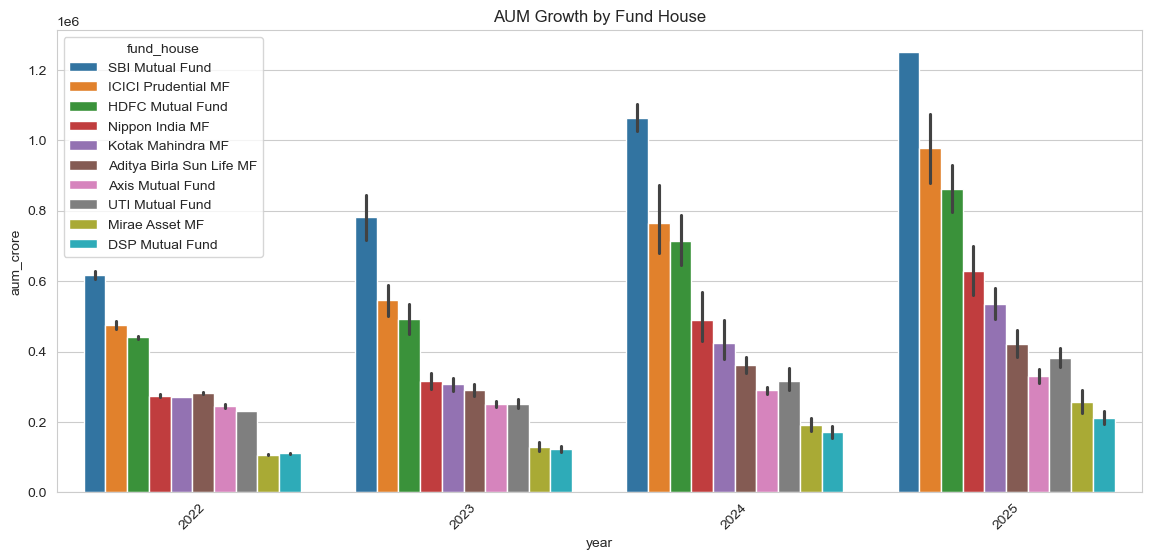

In [23]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.xticks(rotation=45)

plt.show()

In [24]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Trend"
)

fig.show()

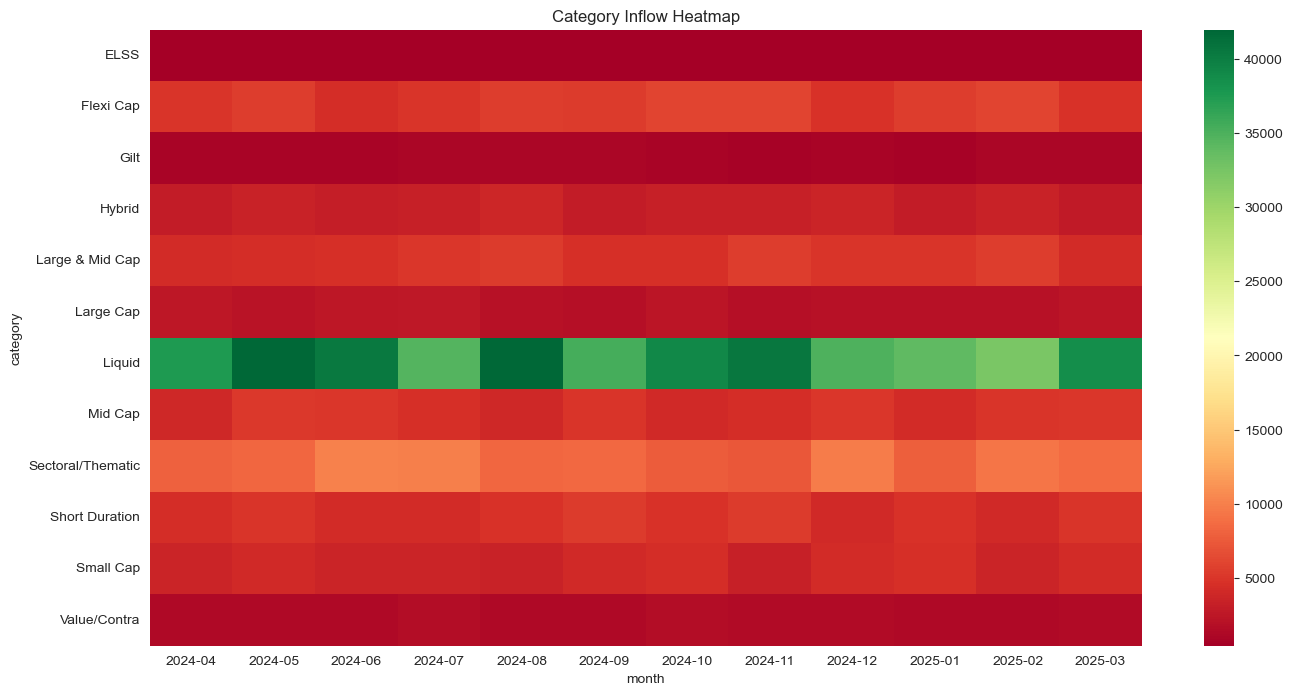

In [25]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn"
)

plt.title("Category Inflow Heatmap")

plt.show()

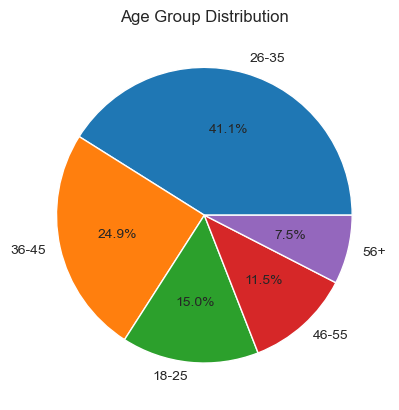

In [26]:
tx["age_group"].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title("Age Group Distribution")

plt.ylabel("")

plt.show()

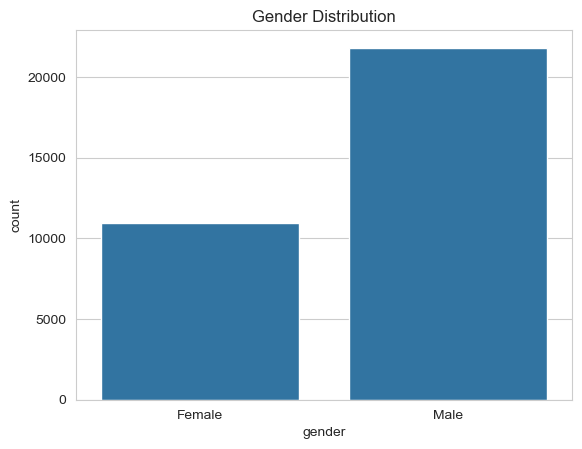

In [27]:
sns.countplot(
    data=tx,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

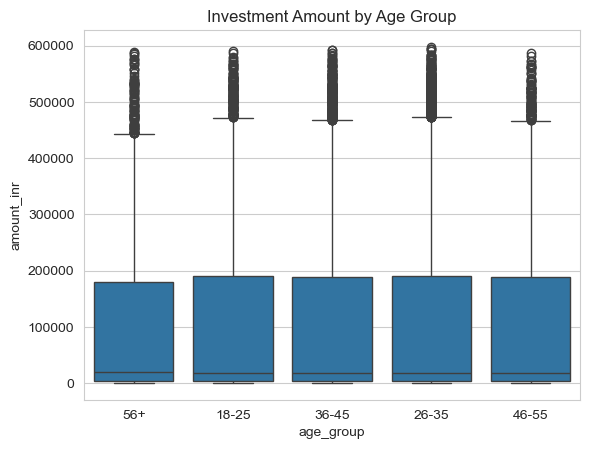

In [28]:
sns.boxplot(
    data=tx,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.show()

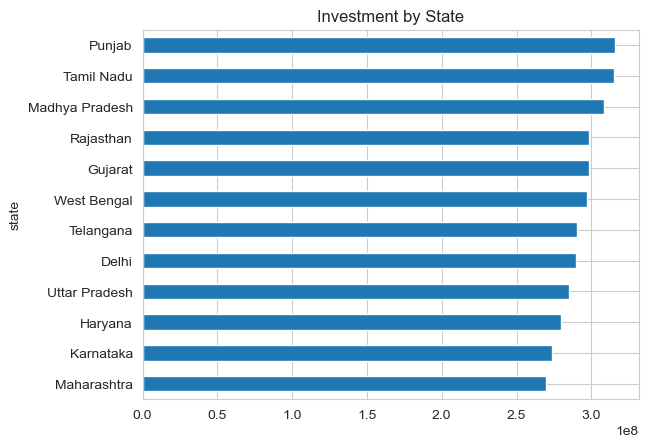

In [29]:
state_data = tx.groupby(
    "state"
)["amount_inr"].sum().sort_values()

state_data.plot.barh()

plt.title("Investment by State")

plt.show()

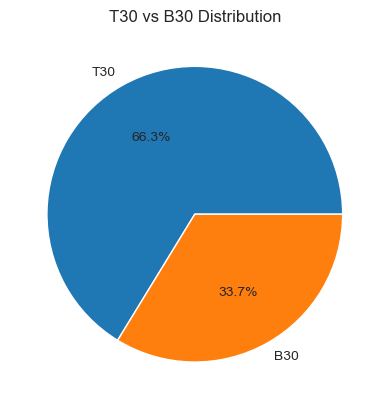

In [30]:
tx["city_tier"].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Distribution")

plt.ylabel("")

plt.show()

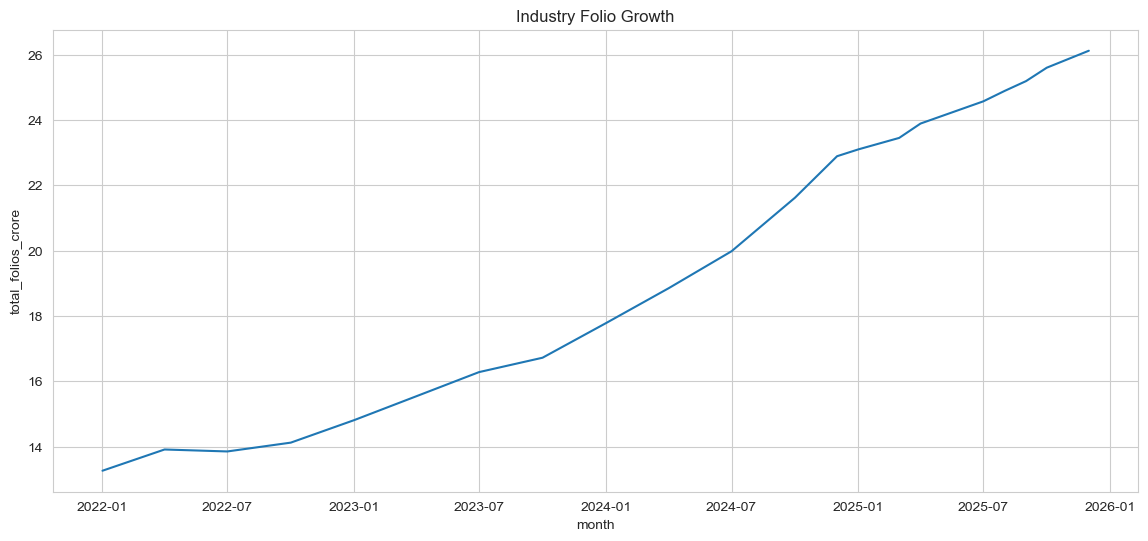

In [31]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=folios,
    x="month",
    y="total_folios_crore"
)

plt.title("Industry Folio Growth")

plt.show()

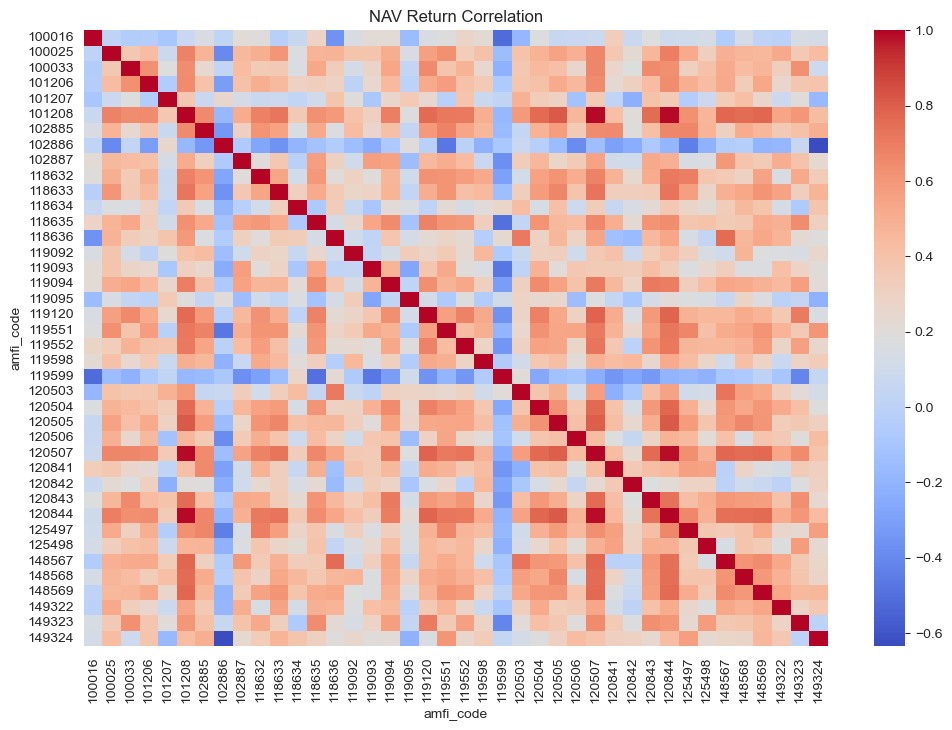

In [32]:
pivot_nav = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")

plt.show()

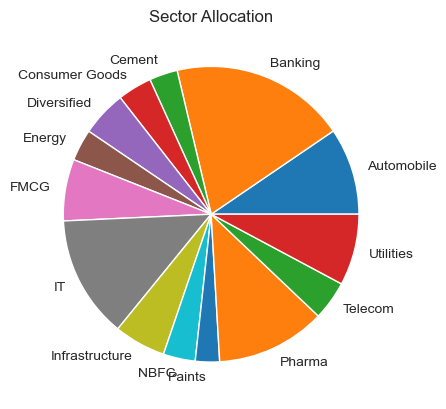

In [33]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.pie(
    sector,
    labels=sector.index
)

plt.title("Sector Allocation")

plt.show()

In [34]:
plt.savefig(
    "../reports/charts/sector_chart.png"
)

<Figure size 640x480 with 0 Axes>